# Part 1: English-to-Chinese Machine Translation

This notebook organizes the complete Part 1 workflow in one file: data loading, Transformer training from scratch, cosine warm-up learning-rate tuning, ablation experiments, learnable positional embedding, checkpoint resume, BLEU evaluation, and result comparison.

The model architecture and tokenization utilities are imported from the submitted source files, while the experiment workflow is written here so the full process can be inspected and rerun.

## 1. Setup

Run this notebook either from the assignment root or from `code/part1_machine_translation/`.

In [1]:
from pathlib import Path
import json
import math
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm.notebook import tqdm

cwd = Path.cwd().resolve()
if cwd.name == "part1_machine_translation":
    PART1_DIR = cwd
    ROOT = PART1_DIR.parents[1]
else:
    ROOT = cwd
    PART1_DIR = ROOT / "code" / "part1_machine_translation"

if str(PART1_DIR) not in sys.path:
    sys.path.insert(0, str(PART1_DIR))

from tokenization import PrepareData, casual_mask
from model.transformer import build_transformer

PAD_ID = 0
UNK_ID = 1
DATA_DIR = PART1_DIR / "data" / "en-cn"
RUNS_ROOT = ROOT / "outputs" / "part1_machine_translation"
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("PART1_DIR:", PART1_DIR)
print("DATA_DIR:", DATA_DIR)
print("RUNS_ROOT:", RUNS_ROOT)
print("CUDA available:", torch.cuda.is_available())

ROOT: D:\code\DP2_work\12533582_assignment2_submission\12533582_assignment2
PART1_DIR: D:\code\DP2_work\12533582_assignment2_submission\12533582_assignment2\code\part1_machine_translation
DATA_DIR: D:\code\DP2_work\12533582_assignment2_submission\12533582_assignment2\code\part1_machine_translation\data\en-cn
RUNS_ROOT: D:\code\DP2_work\12533582_assignment2_submission\12533582_assignment2\outputs\part1_machine_translation
CUDA available: True


## 2. Shared Data Configuration

Data is loaded once and reused by all experiments. For quick checking, keep `USE_MINI_DATA=True`. For formal full training, set it to `False`.

In [2]:
USE_MINI_DATA = False

shared_config = {
    "train_file": "train_mini.txt" if USE_MINI_DATA else "train.txt",
    "dev_file": "dev_mini.txt" if USE_MINI_DATA else "dev.txt",
    "test_file": "test_mini.txt" if USE_MINI_DATA else "test.txt",
    "batch_size": 32 if USE_MINI_DATA else 64,
    "seq_len": 60,
    "seed": 42,
    "eval_every": 5,
    "save_every": 5,
    "eval_max_examples": None,
}

shared_config

{'train_file': 'train.txt',
 'dev_file': 'dev.txt',
 'test_file': 'test.txt',
 'batch_size': 64,
 'seq_len': 60,
 'seed': 42,
 'eval_every': 5,
 'save_every': 5,
 'eval_max_examples': None}

## 3. Shared Utility Functions

These functions are shared by baseline, cosine warm-up, ablation, and positional-embedding experiments.

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ids_to_tokens(ids, index_dict, skip_bos=True):
    tokens = []
    for idx in ids:
        token = index_dict.get(int(idx), "UNK")
        if skip_bos and token == "BOS":
            continue
        if token == "EOS":
            break
        if token != "PAD":
            tokens.append(token)
    return tokens


def get_warmup_cosine_lr(epoch, total_epochs, warmup_epochs, peak_lr, min_lr):
    if warmup_epochs > 0 and epoch <= warmup_epochs:
        return peak_lr * epoch / warmup_epochs
    if total_epochs <= warmup_epochs:
        return min_lr
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    progress = min(max(progress, 0.0), 1.0)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return min_lr + (peak_lr - min_lr) * cosine


def get_lr(epoch, cfg):
    if cfg.get("scheduler") == "warmup_cosine":
        return get_warmup_cosine_lr(epoch, cfg["epochs"], cfg["warmup_epochs"], cfg["peak_lr"], cfg["min_lr"])
    return cfg["lr"]


def set_optimizer_lr(optimizer, lr):
    for group in optimizer.param_groups:
        group["lr"] = lr


def get_ngrams(tokens, max_order=4):
    counts = {}
    for order in range(1, max_order + 1):
        for i in range(0, len(tokens) - order + 1):
            ngram = tuple(tokens[i:i + order])
            counts[ngram] = counts.get(ngram, 0) + 1
    return counts


def compute_bleu(predictions, references, max_order=4):
    matches_by_order = [0] * max_order
    possible_matches_by_order = [0] * max_order
    reference_length = 0
    translation_length = 0
    for prediction, reference in zip(predictions, references):
        pred_tokens = prediction.split()
        ref_tokens = reference.split()
        reference_length += len(ref_tokens)
        translation_length += len(pred_tokens)
        ref_counts = get_ngrams(ref_tokens, max_order)
        pred_counts = get_ngrams(pred_tokens, max_order)
        for ngram, count in pred_counts.items():
            matches_by_order[len(ngram) - 1] += min(count, ref_counts.get(ngram, 0))
        for order in range(1, max_order + 1):
            possible = len(pred_tokens) - order + 1
            if possible > 0:
                possible_matches_by_order[order - 1] += possible
    precisions = [0.0] * max_order
    for i in range(max_order):
        if possible_matches_by_order[i] > 0:
            precisions[i] = matches_by_order[i] / possible_matches_by_order[i]
    geo_mean = math.exp(sum(math.log(p) for p in precisions) / max_order) if min(precisions) > 0 else 0.0
    ratio = translation_length / reference_length if reference_length else 0.0
    bp = 1.0 if ratio > 1.0 else math.exp(1 - 1 / ratio) if ratio > 0 else 0.0
    return {
        "bleu": geo_mean * bp,
        "precisions": precisions,
        "brevity_penalty": bp,
        "length_ratio": ratio,
        "translation_length": translation_length,
        "reference_length": reference_length,
    }


def greedy_decode(model, source, source_mask, tgt_word_dict, max_len, device):
    bos_id = tgt_word_dict["BOS"]
    eos_id = tgt_word_dict["EOS"]
    encoder_output = model.encode(source, source_mask)
    decoder_input = torch.empty(1, 1, dtype=source.dtype, device=device).fill_(bos_id)
    while decoder_input.size(1) < max_len:
        decoder_mask = casual_mask(decoder_input.size(1)).type_as(source_mask).to(device)
        decoder_output = model.decode(encoder_output, source_mask, decoder_input, decoder_mask)
        prob = model.project(decoder_output[:, -1])
        next_word = torch.argmax(prob, dim=1)
        decoder_input = torch.cat([decoder_input, next_word.view(1, 1)], dim=1)
        if next_word.item() == eos_id:
            break
    return decoder_input.squeeze(0).detach().cpu().tolist()


def segment_chinese(sentence):
    import jieba
    words = list(jieba.cut(sentence.strip(), cut_all=False))
    return " ".join(word for word in words if word.strip())


def evaluate_bleu(model, batches, data_obj, max_len, device, prediction_path=None, max_examples=None):
    model.eval()
    rows = []
    predictions_for_bleu = []
    references_for_bleu = []
    with torch.no_grad():
        for i, batch in enumerate(tqdm(batches, desc="Decoding", leave=False)):
            if max_examples is not None and i >= max_examples:
                break
            source = batch.src.to(device)
            source_mask = batch.src_mask.to(device)
            pred_ids = greedy_decode(model, source, source_mask, data_obj.cn_word_dict, max_len, device)
            pred_tokens = ids_to_tokens(pred_ids, data_obj.cn_index_dict)
            ref_tokens = ids_to_tokens(batch.tgt_y.squeeze(0).tolist(), data_obj.cn_index_dict, skip_bos=False)
            src_tokens = ids_to_tokens(batch.src.squeeze(0).tolist(), data_obj.en_index_dict)
            row = {
                "source": " ".join(src_tokens),
                "reference": "".join(ref_tokens),
                "prediction": "".join(pred_tokens),
                "reference_tokens": " ".join(ref_tokens),
                "prediction_tokens": " ".join(pred_tokens),
            }
            rows.append(row)
            predictions_for_bleu.append(segment_chinese(row["prediction"]))
            references_for_bleu.append(segment_chinese(row["reference"]))
    bleu_result = compute_bleu(predictions_for_bleu, references_for_bleu)
    if prediction_path is not None:
        pd.DataFrame(rows).to_csv(prediction_path, sep="\t", index=False)
    return bleu_result["bleu"], rows, bleu_result


def latest_checkpoint(output_dir):
    checkpoints = sorted(output_dir.glob("checkpoint_epoch_*.pt"))
    return checkpoints[-1] if checkpoints else None

## 4. Load Data Once

All experiments reuse the same tokenized data and vocabulary. Each experiment still creates a fresh model and optimizer.

In [4]:
set_seed(shared_config["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_path = DATA_DIR / shared_config["train_file"]
dev_path = DATA_DIR / shared_config["dev_file"]
test_path = DATA_DIR / shared_config["test_file"]

data = PrepareData(str(train_path), str(dev_path), shared_config["batch_size"], UNK_ID, PAD_ID)
test_data = PrepareData(str(train_path), str(test_path), shared_config["batch_size"], UNK_ID, PAD_ID)

src_vocab_size = len(data.en_word_dict)
tgt_vocab_size = len(data.cn_word_dict)

print("device:", device)
print("train/dev/test:", len(data.train_en), len(data.dev_en), len(test_data.dev_en))
print("src_vocab_size:", src_vocab_size)
print("tgt_vocab_size:", tgt_vocab_size)

device: cuda
train/dev/test: 14533 1817 1817
src_vocab_size: 5493
tgt_vocab_size: 2519


## 5. Shared Experiment Runner

`run_experiment` creates a new Transformer from scratch for each experiment, supports interruption recovery, saves checkpoints, evaluates BLEU, and writes output files under that experiment's own directory. Resume settings are written inside each experiment configuration, so a single experiment can be manually resumed without affecting the others.

In [5]:
# Resume a single experiment
# By default, every experiment starts from scratch.
# To resume only one experiment, edit that experiment configuration only:
#
#   "resume_if_available": True,
#   "resume_checkpoint": None,
#
# Or manually point to a specific checkpoint:
#
#   "resume_if_available": False,
#   "resume_checkpoint": r"outputs/part1_machine_translation/cosine_notebook_peak0p0007/checkpoint_epoch_005.pt",
#
# Other experiments are not affected.


In [6]:
def build_model_for_config(cfg):
    return build_transformer(
        src_vocab_size,
        tgt_vocab_size,
        shared_config["seq_len"],
        shared_config["seq_len"],
        cfg["d_model"],
        cfg["n_layer"],
        cfg["heads"],
        cfg.get("dropout", 0.1),
        cfg["d_ff"],
        cfg.get("pe_type", "sinusoidal"),
    ).to(device)


def plot_run_curves(loss_history, lr_history, output_dir):
    if not loss_history:
        return
    loss_df = pd.DataFrame(loss_history)
    lr_df = pd.DataFrame(lr_history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(loss_df["epoch"], loss_df["train_loss"], marker="o")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[1].plot(lr_df["epoch"], lr_df["lr"], marker="o", color="tab:orange")
    axes[1].set_title("Learning Rate")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("LR")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "training_curves.png", dpi=180)
    plt.show()


def run_experiment(experiment_config):
    cfg = {**shared_config, **experiment_config}
    output_dir = RUNS_ROOT / cfg["name"]
    output_dir.mkdir(parents=True, exist_ok=True)

    set_seed(cfg["seed"])
    model = build_model_for_config(cfg)
    loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0, eps=1e-9)

    resume_path = None
    if cfg.get("resume_checkpoint"):
        resume_path = Path(cfg["resume_checkpoint"])
        if not resume_path.is_absolute():
            resume_path = ROOT / resume_path
    elif cfg.get("resume_if_available", False):
        resume_path = latest_checkpoint(output_dir)

    loss_history = []
    lr_history = []
    metrics_history = []
    best_bleu = -math.inf
    start_epoch = 1

    if resume_path is not None and resume_path.exists():
        checkpoint = torch.load(resume_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint["model_state_dict"])
        if "optimizer_state_dict" in checkpoint:
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = int(checkpoint.get("epoch", 0)) + 1
        loss_history = checkpoint.get("loss_history", [])
        lr_history = checkpoint.get("lr_history", [])
        metrics_history = checkpoint.get("metrics_history", [])
        best_bleu = checkpoint.get("best_dev_bleu", -math.inf)
        print(f"[{cfg['name']}] resume from {resume_path}, next epoch={start_epoch}, best_dev_bleu={best_bleu}")
    else:
        print(f"[{cfg['name']}] training from scratch")

    with open(output_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(cfg, f, ensure_ascii=False, indent=2)

    start_time = time.time()
    for epoch in range(start_epoch, cfg["epochs"] + 1):
        current_lr = get_lr(epoch, cfg)
        set_optimizer_lr(optimizer, current_lr)
        lr_history.append({"epoch": epoch, "lr": current_lr})

        model.train()
        total_loss = 0.0
        total_tokens = 0
        iterator = tqdm(data.train_data, desc=f"{cfg['name']} epoch {epoch}/{cfg['epochs']}")
        for batch in iterator:
            encoder_input = batch.src.to(device)
            decoder_input = batch.tgt.to(device)
            encoder_mask = batch.src_mask.to(device)
            decoder_mask = batch.tgt_mask.to(device)
            label = batch.tgt_y.to(device)

            encoder_output = model.encode(encoder_input, encoder_mask)
            decoder_output = model.decode(encoder_output, encoder_mask, decoder_input, decoder_mask)
            proj_output = model.project(decoder_output)

            loss = loss_fn(proj_output.view(-1, tgt_vocab_size), label.view(-1))
            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            ntokens = int(batch.ntokens.item())
            total_loss += loss.item() * ntokens
            total_tokens += ntokens
            iterator.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = total_loss / max(total_tokens, 1)
        loss_history.append({"epoch": epoch, "train_loss": train_loss, "lr": current_lr})

        dev_bleu = None
        should_eval = epoch % cfg.get("eval_every", 5) == 0 or epoch == cfg["epochs"]
        should_save = epoch % cfg.get("save_every", 5) == 0 or epoch == cfg["epochs"]
        if should_eval:
            dev_bleu, _, dev_bleu_result = evaluate_bleu(
                model,
                data.dev_data,
                data,
                cfg["seq_len"],
                device,
                prediction_path=output_dir / "dev_predictions.txt",
                max_examples=cfg.get("eval_max_examples"),
            )
            metrics_history.append({"epoch": epoch, "train_loss": train_loss, "lr": current_lr, "dev_bleu": dev_bleu, "dev_bleu_result": dev_bleu_result})
            if dev_bleu > best_bleu:
                best_bleu = dev_bleu
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "config": cfg,
                        "en_word_dict": data.en_word_dict,
                        "cn_word_dict": data.cn_word_dict,
                        "en_index_dict": data.en_index_dict,
                        "cn_index_dict": data.cn_index_dict,
                        "best_epoch": epoch,
                        "best_dev_bleu": best_bleu,
                        "loss_history": loss_history,
                        "lr_history": lr_history,
                        "metrics_history": metrics_history,
                    },
                    output_dir / "best_model.pt",
                )

        checkpoint_payload = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": cfg,
            "en_word_dict": data.en_word_dict,
            "cn_word_dict": data.cn_word_dict,
            "en_index_dict": data.en_index_dict,
            "cn_index_dict": data.cn_index_dict,
            "epoch": epoch,
            "train_loss": train_loss,
            "loss_history": loss_history,
            "lr_history": lr_history,
            "metrics_history": metrics_history,
            "best_dev_bleu": best_bleu,
        }
        if should_save:
            torch.save(checkpoint_payload, output_dir / f"checkpoint_epoch_{epoch:03d}.pt")
        if dev_bleu is None:
            print(f"{cfg['name']}: epoch={epoch}, lr={current_lr:.8f}, train_loss={train_loss:.4f}")
        else:
            print(f"{cfg['name']}: epoch={epoch}, lr={current_lr:.8f}, train_loss={train_loss:.4f}, dev_bleu={dev_bleu:.4f}")

    with open(output_dir / "loss_history.json", "w", encoding="utf-8") as f:
        json.dump(loss_history, f, ensure_ascii=False, indent=2)
    with open(output_dir / "lr_history.json", "w", encoding="utf-8") as f:
        json.dump(lr_history, f, ensure_ascii=False, indent=2)
    with open(output_dir / "metrics_history.json", "w", encoding="utf-8") as f:
        json.dump(metrics_history, f, ensure_ascii=False, indent=2)

    best_path = output_dir / "best_model.pt"
    if best_path.exists():
        checkpoint = torch.load(best_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint["model_state_dict"])

    test_bleu, test_rows, test_bleu_result = evaluate_bleu(
        model,
        test_data.dev_data,
        test_data,
        cfg["seq_len"],
        device,
        prediction_path=output_dir / "test_predictions.txt",
        max_examples=cfg.get("eval_max_examples"),
    )
    with open(output_dir / "bleu_result.json", "w", encoding="utf-8") as f:
        json.dump(test_bleu_result, f, ensure_ascii=False, indent=2)

    summary = {
        "name": cfg["name"],
        "scheduler": cfg.get("scheduler"),
        "n_layer": cfg["n_layer"],
        "heads": cfg["heads"],
        "d_model": cfg["d_model"],
        "d_ff": cfg["d_ff"],
        "pe_type": cfg.get("pe_type", "sinusoidal"),
        "best_dev_bleu": best_bleu,
        "test_bleu": test_bleu,
        "final_train_loss": loss_history[-1]["train_loss"] if loss_history else None,
        "training_seconds_this_session": time.time() - start_time,
        "num_test_examples": len(test_rows),
        "sample_translations": test_rows[:5],
    }
    with open(output_dir / "summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    plot_run_curves(loss_history, lr_history, output_dir)
    return summary

## 6. Experiment A: Baseline Transformer

This corresponds to `translator_en2cn_baseline.py`: standard Transformer training with a fixed learning rate.

[baseline_default_6_layer] training from scratch


baseline_default_6_layer epoch 1/20:   0%|          | 0/228 [00:00<?, ?it/s]

baseline_default_6_layer: epoch=1, lr=0.00010000, train_loss=5.5015


baseline_default_6_layer epoch 2/20:   0%|          | 0/228 [00:00<?, ?it/s]

baseline_default_6_layer: epoch=2, lr=0.00010000, train_loss=4.5621


...

baseline_default_6_layer: epoch=19, lr=0.00010000, train_loss=1.5630


baseline_default_6_layer epoch 20/20:   0%|          | 0/228 [00:00<?, ?it/s]

Decoding:   0%|          | 0/1817 [00:00<?, ?it/s]

baseline_default_6_layer: epoch=20, lr=0.00010000, train_loss=1.4871, dev_bleu=0.1723


Decoding:   0%|          | 0/1817 [00:00<?, ?it/s]

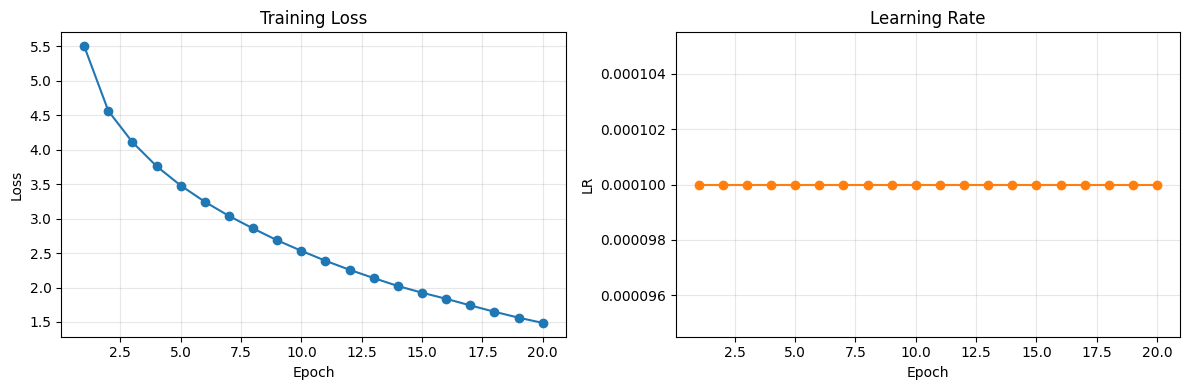

{'name': 'baseline_default_6_layer',
 'best_dev_bleu': 0.1722857213627873,
 'test_bleu': 0.1648096165099206,
 'final_train_loss': 1.4870682638105748}

In [8]:
baseline_config = {
    "name": "baseline_default_6_layer",
    "scheduler": "constant",
    "lr": 1e-4,
    "epochs": 20,
    "n_layer": 6,
    "heads": 8,
    "d_model": 256,
    "d_ff": 1024,
    "dropout": 0.1,
    "pe_type": "sinusoidal",
    "resume_if_available": False,
    "resume_checkpoint": None,
}

baseline_summary = run_experiment(baseline_config)
{
    "name": baseline_summary["name"],
    "best_dev_bleu": baseline_summary["best_dev_bleu"],
    "test_bleu": baseline_summary["test_bleu"],
    "final_train_loss": baseline_summary["final_train_loss"],
}

## 7. Experiment B: Cosine Warm-up Learning Rate Tuning

This corresponds to `translator_en2cn_cosine.py`. The quick setting runs one peak learning rate. For the full tuning experiment, use the full `peak_lrs` list.

[cosine_notebook_peak0p0001] training from scratch


cosine_notebook_peak0p0001 epoch 1/20:   0%|          | 0/228 [00:00<?, ?it/s]

cosine_notebook_peak0p0001: epoch=1, lr=0.00002000, train_loss=6.5249


cosine_notebook_peak0p0001 epoch 2/20:   0%|          | 0/228 [00:00<?, ?it/s]

cosine_notebook_peak0p0001: epoch=2, lr=0.00004000, train_loss=5.3279


...

cosine_notebook_peak0p0001: epoch=19, lr=0.00000208, train_loss=2.3206


cosine_notebook_peak0p0001 epoch 20/20:   0%|          | 0/228 [00:00<?, ?it/s]

Decoding:   0%|          | 0/1817 [00:00<?, ?it/s]

cosine_notebook_peak0p0001: epoch=20, lr=0.00000100, train_loss=2.3167, dev_bleu=0.1044


Decoding:   0%|          | 0/1817 [00:00<?, ?it/s]

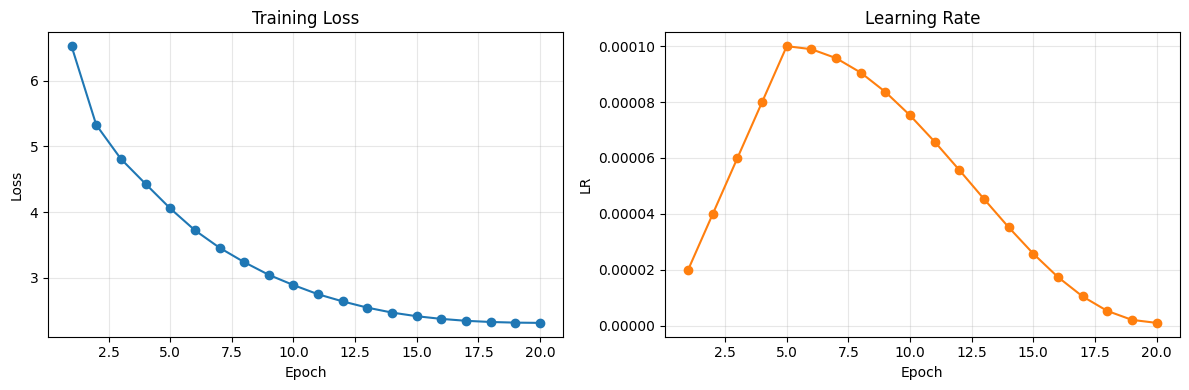

[cosine_notebook_peak0p0002] training from scratch


cosine_notebook_peak0p0002 epoch 1/20:   0%|          | 0/228 [00:00<?, ?it/s]

cosine_notebook_peak0p0002: epoch=1, lr=0.00004000, train_loss=6.0621


cosine_notebook_peak0p0002 epoch 2/20:   0%|          | 0/228 [00:00<?, ?it/s]

cosine_notebook_peak0p0002: epoch=2, lr=0.00008000, train_loss=4.9236


...

cosine_notebook_peak0p0002: epoch=19, lr=0.00000317, train_loss=1.3686


cosine_notebook_peak0p0002 epoch 20/20:   0%|          | 0/228 [00:00<?, ?it/s]

Decoding:   0%|          | 0/1817 [00:00<?, ?it/s]

cosine_notebook_peak0p0002: epoch=20, lr=0.00000100, train_loss=1.3647, dev_bleu=0.1861


Decoding:   0%|          | 0/1817 [00:00<?, ?it/s]

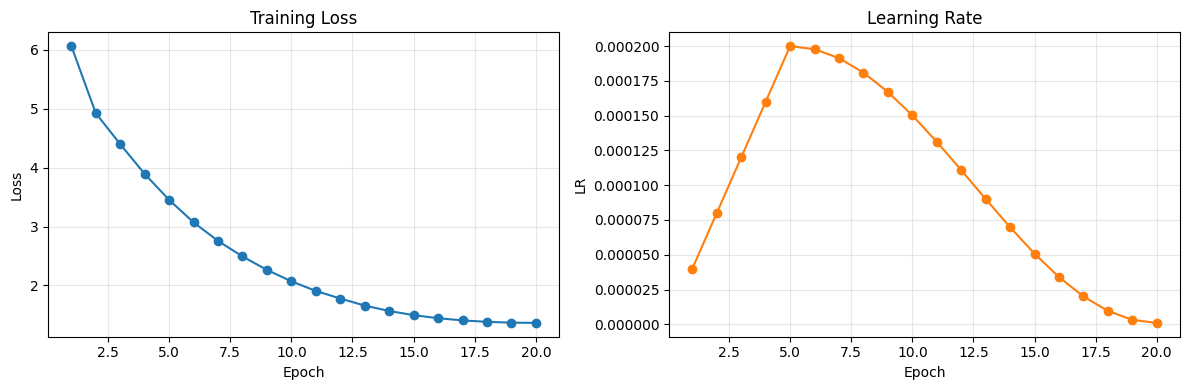

[cosine_notebook_peak0p0003] training from scratch


cosine_notebook_peak0p0003 epoch 1/20:   0%|          | 0/228 [00:00<?, ?it/s]

cosine_notebook_peak0p0003: epoch=1, lr=0.00006000, train_loss=5.7942


cosine_notebook_peak0p0003 epoch 2/20:   0%|          | 0/228 [00:00<?, ?it/s]

cosine_notebook_peak0p0003: epoch=2, lr=0.00012000, train_loss=4.7117


...

cosine_notebook_peak0p0003: epoch=19, lr=0.00000427, train_loss=0.8807


cosine_notebook_peak0p0003 epoch 20/20:   0%|          | 0/228 [00:00<?, ?it/s]

Decoding:   0%|          | 0/1817 [00:00<?, ?it/s]

cosine_notebook_peak0p0003: epoch=20, lr=0.00000100, train_loss=0.8749, dev_bleu=0.2134


Decoding:   0%|          | 0/1817 [00:00<?, ?it/s]

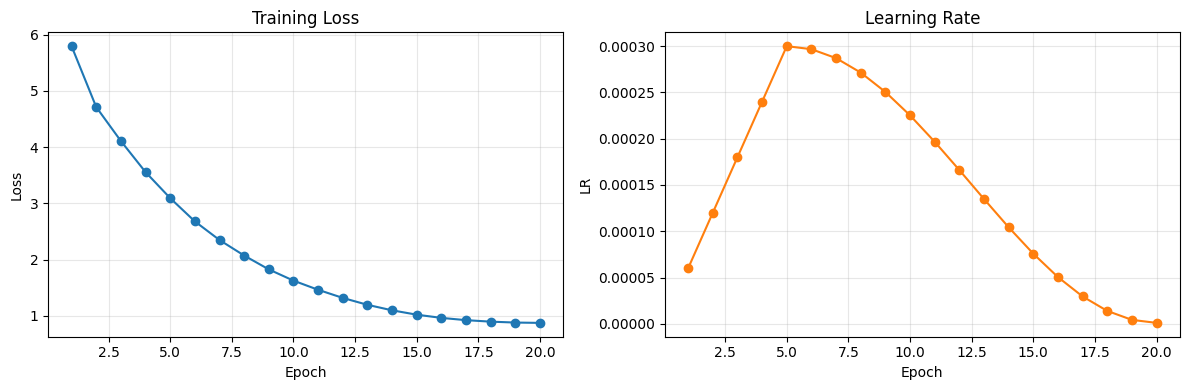

In [9]:
cosine_summaries = []
peak_lrs_1 = [1e-4, 2e-4, 3e-4]

for peak_lr in peak_lrs_1:
    cfg = {
        "name": f"cosine_notebook_peak{peak_lr:g}".replace(".", "p"),
        "scheduler": "warmup_cosine",
        "peak_lr": peak_lr,
        "min_lr": 1e-6,
        "warmup_epochs": 5,
        "epochs": 20,
        "n_layer": 6,
        "heads": 8,
        "d_model": 256,
        "d_ff": 1024,
        "dropout": 0.1,
        "pe_type": "sinusoidal",
        "resume_if_available": False,
        "resume_checkpoint": None,
    }
    cosine_summaries.append(run_experiment(cfg))


In [ ]:
peak_lrs_2 = [4e-4, 5e-4, 6e-4]

for peak_lr in peak_lrs_2:
    cfg = {
        "name": f"cosine_notebook_peak{peak_lr:g}".replace(".", "p"),
        "scheduler": "warmup_cosine",
        "peak_lr": peak_lr,
        "min_lr": 1e-6,
        "warmup_epochs": 5,
        "epochs": 20,
        "n_layer": 6,
        "heads": 8,
        "d_model": 256,
        "d_ff": 1024,
        "dropout": 0.1,
        "pe_type": "sinusoidal",
        "resume_if_available": False,
        "resume_checkpoint": None,
    }
    cosine_summaries.append(run_experiment(cfg))


In [ ]:
peak_lrs_3 = [7e-4, 8e-4]

for peak_lr in peak_lrs_3:
    cfg = {
        "name": f"cosine_notebook_peak{peak_lr:g}".replace(".", "p"),
        "scheduler": "warmup_cosine",
        "peak_lr": peak_lr,
        "min_lr": 1e-6,
        "warmup_epochs": 5,
        "epochs": 20,
        "n_layer": 6,
        "heads": 8,
        "d_model": 256,
        "d_ff": 1024,
        "dropout": 0.1,
        "pe_type": "sinusoidal",
        "resume_if_available": False,
        "resume_checkpoint": None,
    }
    cosine_summaries.append(run_experiment(cfg))




In [ ]:
pd.DataFrame(cosine_summaries).sort_values("test_bleu", ascending=False)

## 8. Experiment C: Hyperparameter Ablation

This corresponds to `translator_en2cn_ablation.py`. Each ablation starts from a fresh model and uses its own output directory.

In [ ]:
ablation_configs = [
    {"name": "ablation_notebook_nlayer3", "n_layer": 1 if USE_MINI_DATA else 3, "heads": 4 if USE_MINI_DATA else 8, "d_model": 128 if USE_MINI_DATA else 256, "d_ff": 256 if USE_MINI_DATA else 1024},
    {"name": "ablation_notebook_heads4", "n_layer": 2 if USE_MINI_DATA else 6, "heads": 2 if USE_MINI_DATA else 4, "d_model": 128 if USE_MINI_DATA else 256, "d_ff": 256 if USE_MINI_DATA else 1024},
    {"name": "ablation_notebook_dmodel128", "n_layer": 2 if USE_MINI_DATA else 6, "heads": 4 if USE_MINI_DATA else 8, "d_model": 64 if USE_MINI_DATA else 128, "d_ff": 128 if USE_MINI_DATA else 512},
]

ablation_summaries = []
for cfg in ablation_configs:
    cfg = {
        **cfg,
        "scheduler": "warmup_cosine",
        "peak_lr": 7e-4,
        "min_lr": 1e-6,
        "warmup_epochs": 1 if USE_MINI_DATA else 5,
        "epochs": 1 if USE_MINI_DATA else 20,
        "dropout": 0.1,
        "pe_type": "sinusoidal",
        "resume_if_available": False,
        "resume_checkpoint": None,
    }
    ablation_summaries.append(run_experiment(cfg))

pd.DataFrame(ablation_summaries).sort_values("test_bleu", ascending=False)

## 9. Experiment D: Learnable Positional Embedding

This experiment changes positional encoding from sinusoidal to learnable while keeping the main cosine warm-up setup.

In [ ]:
learnable_pe_config = {
    "name": "learnable_pe_notebook",
    "scheduler": "warmup_cosine",
    "peak_lr": 7e-4,
    "min_lr": 1e-6,
    "warmup_epochs": 1 if USE_MINI_DATA else 5,
    "epochs": 1 if USE_MINI_DATA else 20,
    "n_layer": 2 if USE_MINI_DATA else 6,
    "heads": 4 if USE_MINI_DATA else 8,
    "d_model": 128 if USE_MINI_DATA else 256,
    "d_ff": 256 if USE_MINI_DATA else 1024,
    "dropout": 0.1,
    "pe_type": "learnable",
    "resume_if_available": False,
    "resume_checkpoint": None,
}

learnable_pe_summary = run_experiment(learnable_pe_config)
learnable_pe_summary

## 10. Compare All Notebook Runs

This scans saved `summary.json` files and creates a comparison table.

In [ ]:
rows = []
for summary_path in sorted(RUNS_ROOT.glob("*/summary.json")):
    with open(summary_path, "r", encoding="utf-8") as f:
        row = json.load(f)
    row["output_dir"] = str(summary_path.parent.relative_to(ROOT))
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.sort_values("test_bleu", ascending=False) if not summary_df.empty else summary_df